# 14. Host Fraction Gaussian Story Figures (Plot-Focused)

This notebook generates only the figure and table outputs used for the
manuscript host-fraction figure story.
- No bootstrap RLRT is performed in this notebook.
- Random-effect inference uses chi-square LRT p-values.
- Focused panel contrasts are plotted as acute-like vs others and
  upper-extremity vs others, while p-values are reported from the full model.

In [1]:
from pathlib import Path
import re
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import SVG, Markdown, display
from matplotlib.ticker import PercentFormatter
from scipy.stats import chi2, mannwhitneyu
from statsmodels.stats.multitest import multipletests

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import workflow_core as wc

context, base_data, base, advanced = wc.bootstrap_notebook()
sns.set_theme(style="whitegrid", context="talk")

## Prepare Host Table And Fit Gaussian Mixed Models

In [2]:
METHODS = ["lbfgs", "powell", "bfgs"]
FULL_FORMULA = (
    "host_logit ~ C(body_region, Treatment('lower_extremity')) "
    "+ C(chronicity_group, Treatment('unknown')) "
    "+ C(culture_positive_label, Treatment('negative')) + years_since_first_sample"
)
VC_BOTH = {"patient": "0 + C(patient_id)", "batch": "0 + C(batch_id)"}
VC_PATIENT = {"patient": "0 + C(patient_id)"}
VC_BATCH = {"batch": "0 + C(batch_id)"}


def coerce_for_mixedlm(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy().reset_index(drop=True)
    # Keep patsy/statsmodels on numpy-backed/object arrays, avoiding Arrow/string
    # extension dtype incompatibilities.
    for col in out.columns:
        out[col] = pd.Series(out[col].to_numpy(), index=out.index)
        dtype_str = str(out[col].dtype)
        if dtype_str.startswith("string") or dtype_str == "str":
            out[col] = out[col].astype(object)
    out["all_group"] = "all"
    out["all_group"] = out["all_group"].astype(object)
    return out


def fit_best_mixedlm(
    frame: pd.DataFrame,
    formula: str,
    vc_formula: dict[str, str],
    methods: list[str] = METHODS,
) -> tuple[object, dict[str, object]]:
    work = coerce_for_mixedlm(frame)
    candidates = []
    last_error = None
    for method in methods:
        try:
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter("always")
                fit = smf.mixedlm(
                    formula=formula,
                    data=work,
                    groups=work["all_group"],
                    vc_formula=vc_formula,
                ).fit(reml=False, method=method, maxiter=500, disp=False)
            candidates.append((fit, method, [str(item.message) for item in caught]))
        except Exception as exc:
            last_error = exc

    if not candidates:
        raise RuntimeError(last_error)

    converged = [item for item in candidates if bool(getattr(item[0], "converged", False))]
    pool = converged if converged else candidates
    fit, optimizer, warns = min(pool, key=lambda item: item[0].aic)
    meta = {
        "optimizer": optimizer,
        "warning_count": len(warns),
        "warnings": " | ".join(sorted(set(warns)))[:2000],
    }
    return fit, meta


def lrt_chisq(full_fit, reduced_fit, df_diff: int = 1) -> tuple[float, float]:
    lrt = max(0.0, 2.0 * (full_fit.llf - reduced_fit.llf))
    p = float(chi2.sf(lrt, df_diff))
    return float(lrt), p


host_plot_df = base_data["qc"].dropna(
    subset=[
        "host_removed_fraction",
        "host_logit",
        "body_region",
        "chronicity_group",
        "patient_id",
        "batch_id",
        "culture_positive_label",
        "years_since_first_sample",
    ]
).copy()

host_plot_df["acute_like_binary"] = np.where(
    host_plot_df["chronicity_group"].astype(str) == "acute_like", "Acute-like", "Others"
)
host_plot_df["upper_extremity_binary"] = np.where(
    host_plot_df["body_region"].astype(str) == "upper_extremity",
    "Upper extremity",
    "Others",
)

# Descriptive one-sided Mann-Whitney U tests used as naive pre-model checks.
def descriptive_utest_table(frame: pd.DataFrame) -> pd.DataFrame:
    tests = [
        {
            "contrast": "acute_like_vs_others",
            "group_col": "acute_like_binary",
            "positive_label": "Acute-like",
        },
        {
            "contrast": "upper_extremity_vs_others",
            "group_col": "upper_extremity_binary",
            "positive_label": "Upper extremity",
        },
    ]
    rows = []
    for spec in tests:
        pos = frame.loc[
            frame[spec["group_col"]].astype(str) == spec["positive_label"],
            "host_removed_fraction",
        ].astype(float)
        neg = frame.loc[
            frame[spec["group_col"]].astype(str) != spec["positive_label"],
            "host_removed_fraction",
        ].astype(float)
        u_greater, p_greater = mannwhitneyu(pos, neg, alternative="greater")
        u_two, p_two = mannwhitneyu(pos, neg, alternative="two-sided")
        rows.append(
            {
                "contrast": spec["contrast"],
                "n_positive": int(pos.shape[0]),
                "n_other": int(neg.shape[0]),
                "median_positive": float(pos.median()),
                "median_other": float(neg.median()),
                "u_statistic": float(u_greater),
                "pvalue_one_sided_greater": float(p_greater),
                "pvalue_two_sided": float(p_two),
            }
        )
    return pd.DataFrame(rows)

utest_table = descriptive_utest_table(host_plot_df)
utest_out = context.table_dir / "table_14_03_host_descriptive_utests.tsv"
utest_table.to_csv(utest_out, sep="	", index=False)

full_fit, full_meta = fit_best_mixedlm(host_plot_df, FULL_FORMULA, VC_BOTH)
patient_fit, patient_meta = fit_best_mixedlm(host_plot_df, FULL_FORMULA, VC_PATIENT)
batch_fit, batch_meta = fit_best_mixedlm(host_plot_df, FULL_FORMULA, VC_BATCH)
fixed_only = smf.ols(FULL_FORMULA, data=coerce_for_mixedlm(host_plot_df)).fit()

# Random-effect chi-square LRT p-values (no bootstrap).
tests = []
for tested_effect, full_m, reduced_m in [
    ("patient_only_vs_fixed", patient_fit, fixed_only),
    ("batch_only_vs_fixed", batch_fit, fixed_only),
    ("batch_added_to_patient", full_fit, patient_fit),
    ("patient_added_to_batch", full_fit, batch_fit),
]:
    lrt, p_chisq = lrt_chisq(full_m, reduced_m, df_diff=1)
    tests.append(
        {
            "record_type": "random_effect_test",
            "tested_effect": tested_effect,
            "lrt_statistic": lrt,
            "pvalue_chisq": p_chisq,
        }
    )
lrt_table = pd.DataFrame(tests)

# Full-model fixed-effect rows (for q-values and manuscript values).
effect_rows = []
for term in full_fit.params.index:
    if term == "Intercept" or " Var" in term:
        continue
    effect_rows.append(
        {
            "record_type": "full_model_term",
            "term": term,
            "estimate": float(full_fit.params[term]),
            "conf_low": float(full_fit.conf_int().loc[term, 0]),
            "conf_high": float(full_fit.conf_int().loc[term, 1]),
            "pvalue": float(full_fit.pvalues[term]),
        }
    )
effects_table = pd.DataFrame(effect_rows)
if not effects_table.empty:
    effects_table["qvalue"] = multipletests(effects_table["pvalue"], method="fdr_bh")[1]

acute_term = "C(chronicity_group, Treatment('unknown'))[T.acute_like]"
upper_term = "C(body_region, Treatment('lower_extremity'))[T.upper_extremity]"
acute_p_full = float(effects_table.loc[effects_table["term"] == acute_term, "pvalue"].iloc[0])
upper_p_full = float(effects_table.loc[effects_table["term"] == upper_term, "pvalue"].iloc[0])
acute_q_full = float(effects_table.loc[effects_table["term"] == acute_term, "qvalue"].iloc[0])
upper_q_full = float(effects_table.loc[effects_table["term"] == upper_term, "qvalue"].iloc[0])

followup_table = pd.concat(
    [
        effects_table,
        lrt_table,
        pd.DataFrame(
            [
                {
                    "record_type": "binary_plot_contrast",
                    "term": "acute_like_vs_others",
                    "estimate": np.nan,
                    "conf_low": np.nan,
                    "conf_high": np.nan,
                    "pvalue": acute_p_full,
                    "qvalue": acute_q_full,
                },
                {
                    "record_type": "binary_plot_contrast",
                    "term": "upper_extremity_vs_others",
                    "estimate": np.nan,
                    "conf_low": np.nan,
                    "conf_high": np.nan,
                    "pvalue": upper_p_full,
                    "qvalue": upper_q_full,
                },
            ]
        ),
    ],
    ignore_index=True,
)
wc.save_table(followup_table, wc.table_path(context, 36, "host_gaussian_followup"))

# Extract random intercepts for patient/batch panels.
re_series = (
    full_fit.random_effects[next(iter(full_fit.random_effects))]
    .rename("random_intercept")
    .reset_index()
)
re_series = re_series.rename(columns={"index": "raw_label"})
pattern = re.compile(r"^(batch|patient)\[C\((?:batch_id|patient_id)\)\[(.+)\]\]$")
random_rows = []
for _, row in re_series.iterrows():
    m = pattern.match(row["raw_label"])
    if m is None:
        continue
    random_rows.append(
        {"group": m.group(1), "level": m.group(2), "random_intercept": row["random_intercept"]}
    )
random_effects_df = pd.DataFrame(random_rows).sort_values(["group", "random_intercept"])
wc.save_table(random_effects_df, wc.table_path(context, 37, "host_gaussian_random_effects"))

PosixPath('/home/ubuntu/dev/20250320_eb_summary/metagenomics_20260206/analysis_update/tables/table_14_02_host_gaussian_random_effects.tsv')

## Figure 18. Host Fraction Overview

/tmp/ipykernel_355165/4289546086.py:146: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(
/tmp/ipykernel_355165/4289546086.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
/tmp/ipykernel_355165/4289546086.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
/tmp/ipykernel_355165/4289546086.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


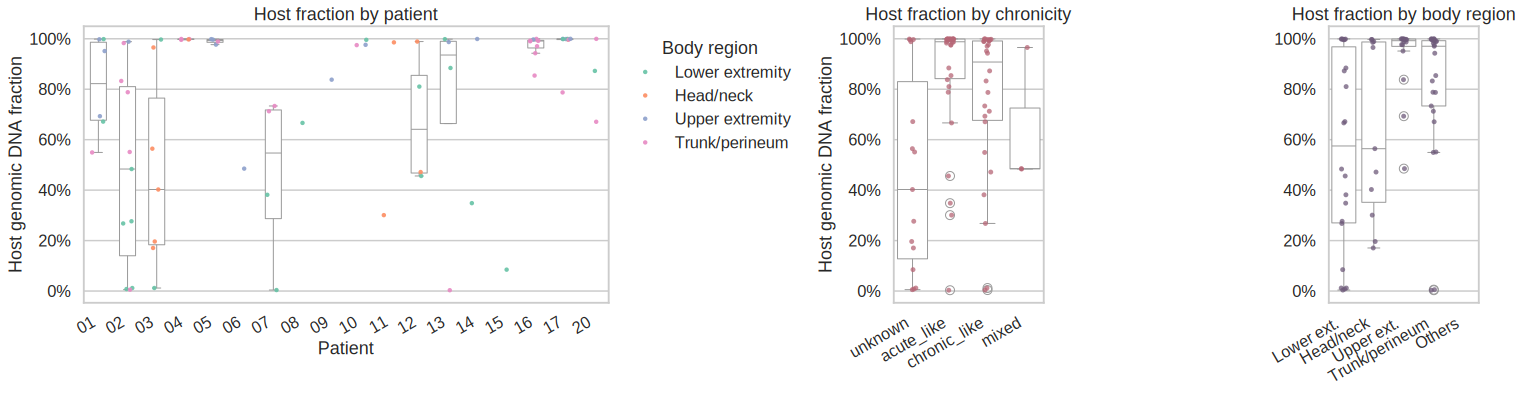

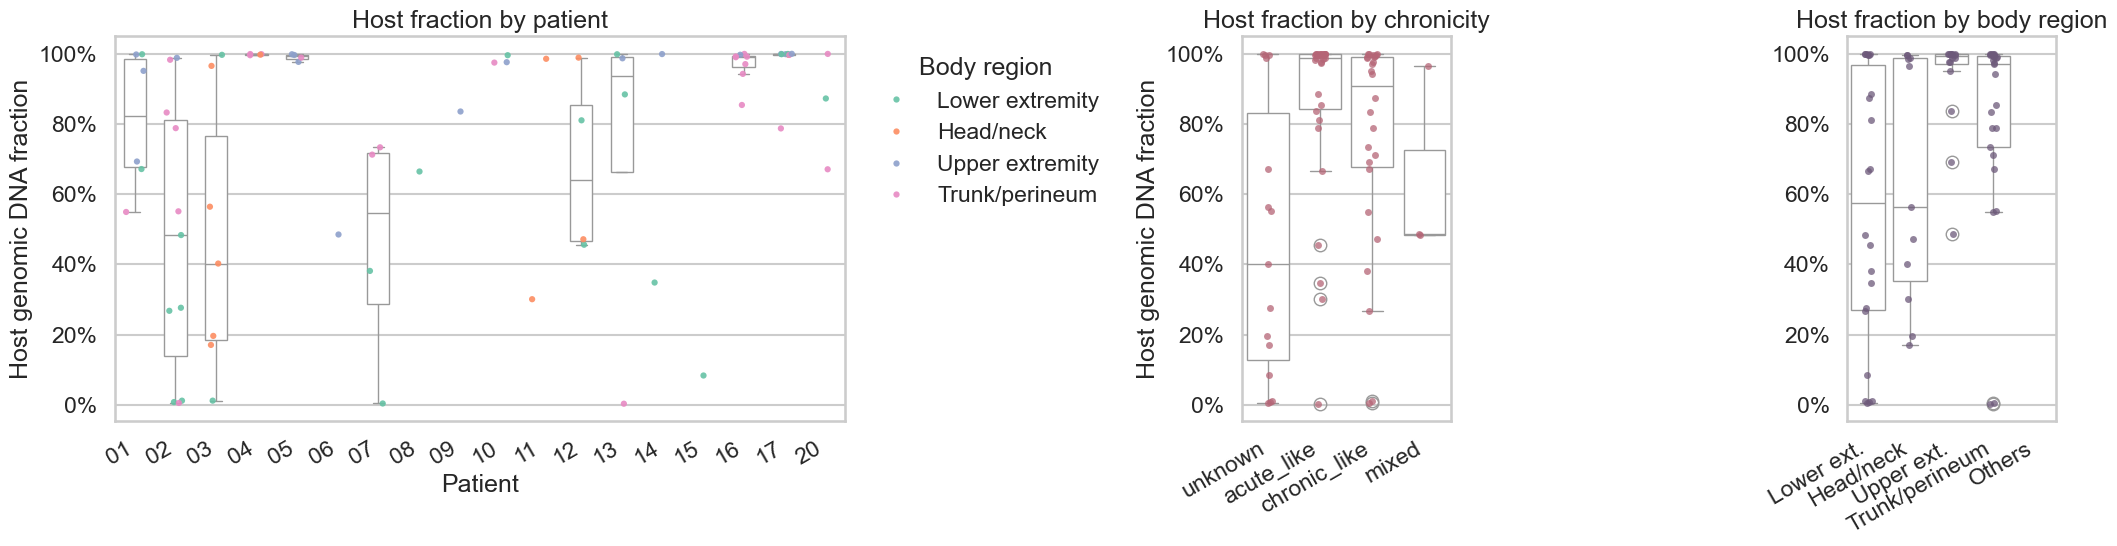

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5.8), gridspec_kw={"width_ratios": [3.5, 1.0, 1.0]})

patient_order = (
    host_plot_df["patient_id"]
    .astype(str)
    .dropna()
    .drop_duplicates()
    .sort_values(key=lambda s: pd.to_numeric(s, errors="coerce").fillna(9999))
    .tolist()
)
body_region_order = [
    region
    for region in ["lower_extremity", "head_neck", "upper_extremity", "trunk_perineum", "others"]
    if region in set(host_plot_df["body_region"].astype(str))
]
if not body_region_order:
    body_region_order = sorted(host_plot_df["body_region"].dropna().astype(str).unique().tolist())
body_region_labels = {
    "lower_extremity": "Lower extremity",
    "head_neck": "Head/neck",
    "upper_extremity": "Upper extremity",
    "trunk_perineum": "Trunk/perineum",
    "others": "Others",
}
body_palette = dict(
    zip(body_region_order, sns.color_palette("Set2", n_colors=len(body_region_order)))
)
chronicity_order = ["unknown", "acute_like", "chronic_like", "mixed"]
chronicity_order = [
    value for value in chronicity_order if value in set(host_plot_df["chronicity_group"].astype(str))
]
if not chronicity_order:
    chronicity_order = sorted(host_plot_df["chronicity_group"].dropna().astype(str).unique().tolist())
chronicity_labels = {
    "unknown": "Unknown",
    "acute_like": "Acute-like",
    "chronic_like": "Chronic-like",
    "mixed": "Mixed",
}
chronicity_palette = dict(
    zip(chronicity_order, sns.color_palette("Set2", n_colors=len(chronicity_order)))
)

patient_counts = host_plot_df["patient_id"].astype(str).value_counts()
box_patients = set(patient_counts[patient_counts > 3].index.tolist())
box_df = host_plot_df.loc[host_plot_df["patient_id"].astype(str).isin(box_patients)].copy()

if not box_df.empty:
    sns.boxplot(
        data=box_df,
        x="patient_id",
        y="host_removed_fraction",
        order=patient_order,
        color="white",
        fliersize=0,
        width=0.55,
        linewidth=1.0,
        ax=axes[0],
    )
sns.stripplot(
    data=host_plot_df,
    x="patient_id",
    y="host_removed_fraction",
    hue="chronicity_group",
    order=patient_order,
    hue_order=chronicity_order,
    palette=chronicity_palette,
    dodge=False,
    jitter=0.22,
    size=4.5,
    alpha=0.9,
    ax=axes[0],
)
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    display_labels = [chronicity_labels.get(label, label) for label in labels]
    axes[0].legend(
        handles,
        display_labels,
        title="Chronicity",
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        frameon=False,
    )
for boundary in np.arange(0.5, max(len(patient_order) - 0.5, 0.5), 1.0):
    axes[0].axvline(boundary, color="#e0e0e0", linewidth=0.8, zorder=0)
axes[0].set_xlim(-0.5, len(patient_order) - 0.5)
axes[0].set_title("Host fraction by patient")
axes[0].set_xlabel("Patient")
axes[0].set_ylabel("Host genomic DNA fraction")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))

sns.boxplot(
    data=host_plot_df,
    x="chronicity_group",
    y="host_removed_fraction",
    order=chronicity_order,
    color="white",
    fliersize=0,
    ax=axes[1],
)
sns.stripplot(
    data=host_plot_df,
    x="chronicity_group",
    y="host_removed_fraction",
    order=chronicity_order,
    color="#b56576",
    size=5,
    alpha=0.75,
    ax=axes[1],
)
axes[1].set_title("Host fraction by chronicity")
axes[1].set_xlabel("")
axes[1].set_ylabel("Host genomic DNA fraction")
axes[1].tick_params(axis="x", rotation=25)
axes[1].yaxis.set_major_formatter(PercentFormatter(1))

body_order = [
    region for region in body_region_order if host_plot_df["body_region"].astype(str).eq(region).any()
]
sns.boxplot(
    data=host_plot_df,
    x="body_region",
    y="host_removed_fraction",
    order=body_order,
    color="white",
    fliersize=0,
    ax=axes[2],
)
sns.stripplot(
    data=host_plot_df,
    x="body_region",
    y="host_removed_fraction",
    order=body_order,
    color="#6d597a",
    size=5,
    alpha=0.75,
    ax=axes[2],
)
axes[2].set_title("Host fraction by body region")
axes[2].set_xlabel("")
axes[2].set_ylabel("")
body_tick_labels = {
    "lower_extremity": "Lower ext.",
    "head_neck": "Head/neck",
    "upper_extremity": "Upper ext.",
    "trunk_perineum": "Trunk/perineum",
    "others": "Others",
}
axes[2].set_xticks(np.arange(len(body_order)))
axes[2].set_xticklabels([body_tick_labels.get(label, label) for label in body_order], rotation=25)
axes[2].yaxis.set_major_formatter(PercentFormatter(1))

for ax in axes:
    ax.tick_params(axis="x", labelrotation=30)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")

fig.tight_layout()
fig_14_01_path = wc.figure_path(context, 18, "host_fraction_overview")
fig.savefig(fig_14_01_path, bbox_inches="tight")
fig.savefig(fig_14_01_path.with_suffix(".jpg"), bbox_inches="tight", dpi=300)
display(SVG(filename=str(fig_14_01_path)))

## Figure 19. Gaussian Mixed-Model Summary (Variance + Chi-square LRT)

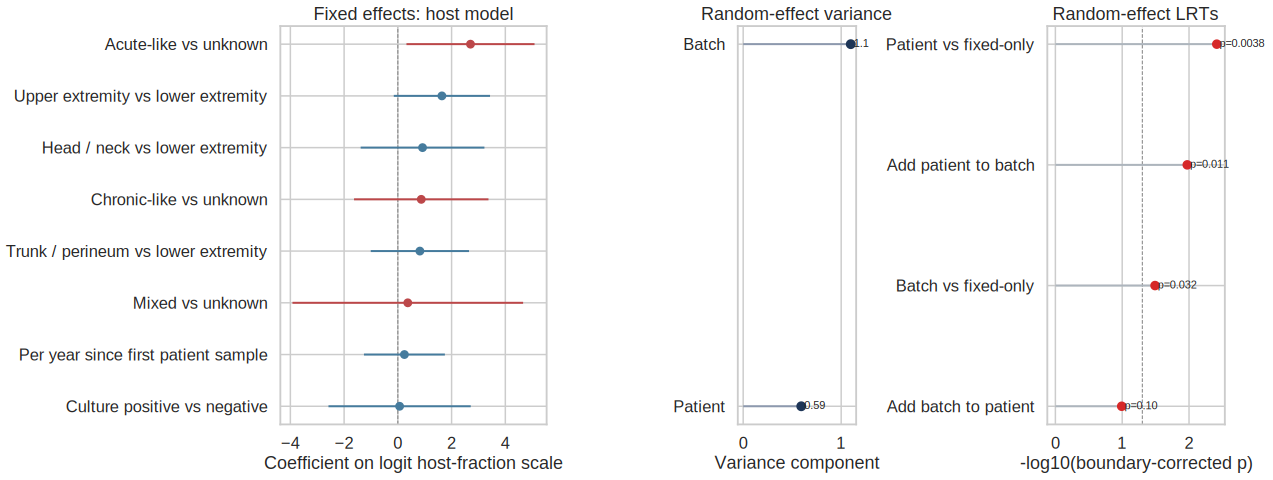

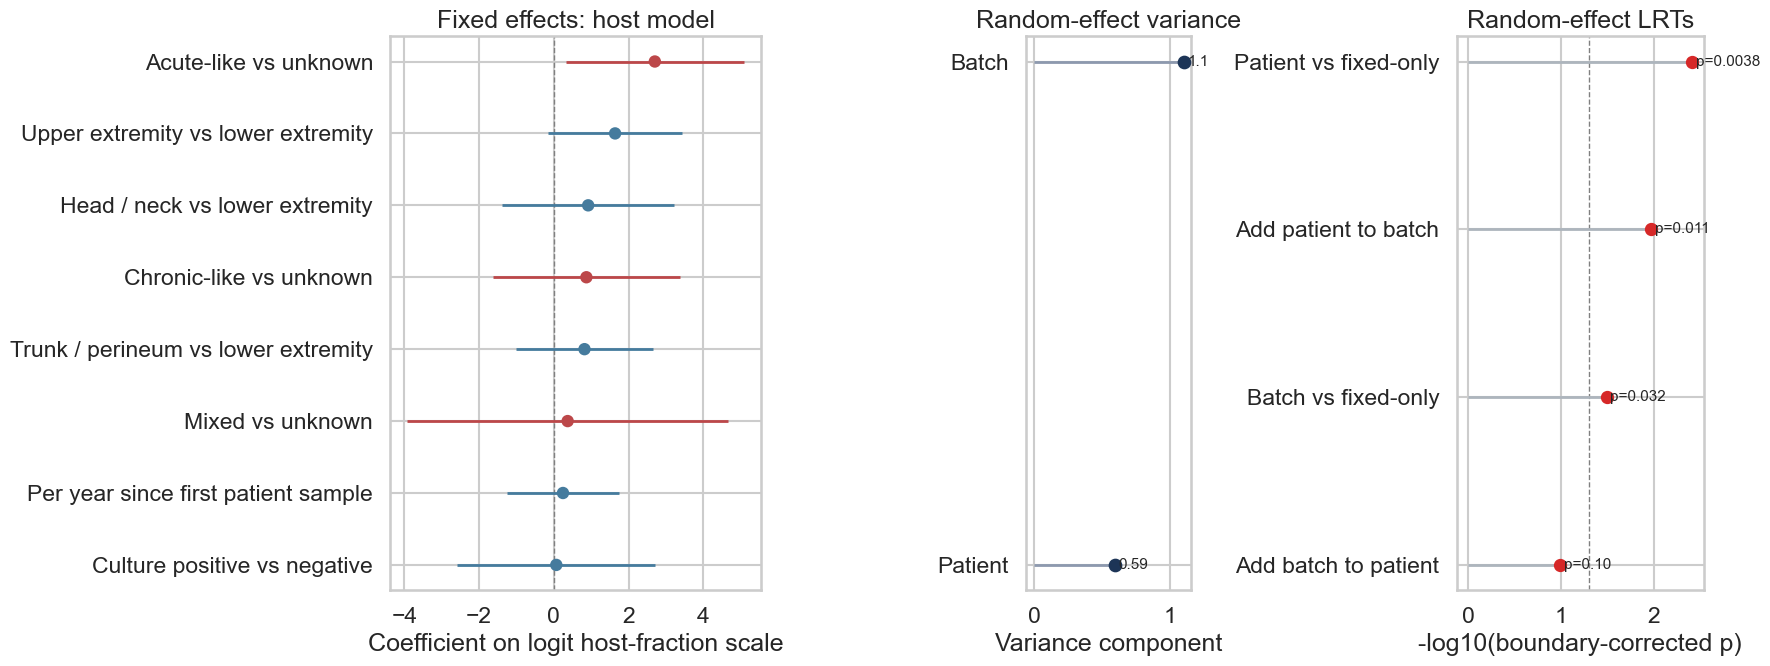

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6), gridspec_kw={"width_ratios": [0.9, 1.4]})
ax_var, ax_lrt = axes

vc_names = list(full_fit.model.exog_vc.names)
vcomp = list(full_fit.vcomp)
var_map = {name: float(val) for name, val in zip(vc_names, vcomp)}
var_df = pd.DataFrame(
    {
        "component": ["Patient", "Batch"],
        "variance": [var_map.get("patient", np.nan), var_map.get("batch", np.nan)],
    }
)
ax_var.hlines(var_df["component"], 0, var_df["variance"], color="#8d99ae", linewidth=2)
ax_var.scatter(var_df["variance"], var_df["component"], color="#1d3557", s=70, zorder=3)
for _, row in var_df.iterrows():
    ax_var.text(
        row["variance"] + 0.03,
        row["component"],
        wc.format_sig(row["variance"]),
        va="center",
        fontsize=11,
    )
ax_var.set_title("Random-effect variance")
ax_var.set_xlabel("Variance component")

label_map = {
    "patient_only_vs_fixed": "Patient vs fixed-only",
    "batch_only_vs_fixed": "Batch vs fixed-only",
    "batch_added_to_patient": "Add batch to patient",
    "patient_added_to_batch": "Add patient to batch",
}
lrt_plot = lrt_table.copy()
lrt_plot["test_label"] = lrt_plot["tested_effect"].map(label_map)
lrt_plot["neglog10_p"] = -np.log10(lrt_plot["pvalue_chisq"].clip(lower=1e-12))
lrt_plot = lrt_plot.sort_values("neglog10_p")
ax_lrt.axvline(-np.log10(0.05), color="grey", linestyle="--", linewidth=1)
ax_lrt.hlines(lrt_plot["test_label"], 0, lrt_plot["neglog10_p"], color="#adb5bd", linewidth=2)
ax_lrt.scatter(lrt_plot["neglog10_p"], lrt_plot["test_label"], color="#d62828", s=65, zorder=3)
for _, row in lrt_plot.iterrows():
    ax_lrt.text(
        row["neglog10_p"] + 0.04,
        row["test_label"],
        f"p={wc.format_sig(row['pvalue_chisq'])}",
        va="center",
        fontsize=11,
    )
ax_lrt.set_title("Random-effect LRTs (chi-square p)")
ax_lrt.set_xlabel("-log10(chi-square p)")

fig.tight_layout()
fig_14_02_path = wc.figure_path(context, 19, "host_gaussian_mixed_summary")
fig.savefig(fig_14_02_path, bbox_inches="tight")
fig.savefig(fig_14_02_path.with_suffix(".jpg"), bbox_inches="tight", dpi=300)
display(SVG(filename=str(fig_14_02_path)))

## Figure 20. Focused Binary Panels (Acute-like/Others; Upper-Extremity/Others)

/tmp/ipykernel_355165/3832814349.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_355165/3832814349.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


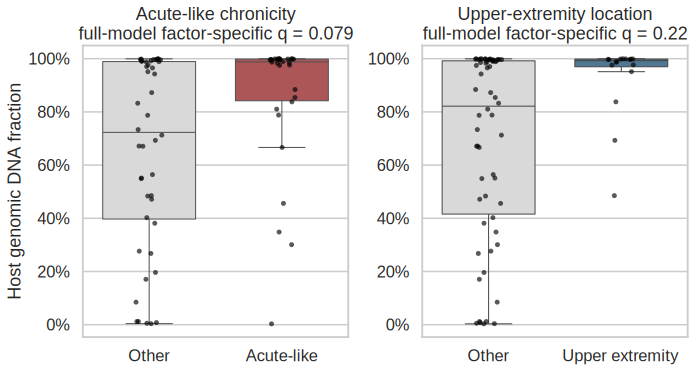

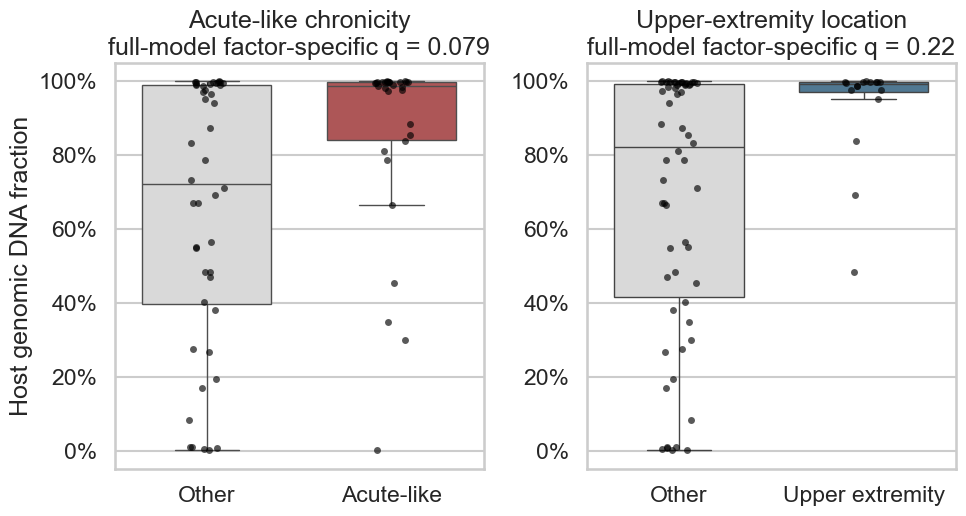

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5.5))

sns.boxplot(
    data=host_plot_df,
    x="acute_like_binary",
    y="host_removed_fraction",
    hue="acute_like_binary",
    order=["Others", "Acute-like"],
    hue_order=["Others", "Acute-like"],
    palette={"Others": "#d9d9d9", "Acute-like": "#bc4749"},
    dodge=False,
    width=0.7,
    fliersize=0,
    legend=False,
    ax=axes[0],
)
sns.stripplot(
    data=host_plot_df,
    x="acute_like_binary",
    y="host_removed_fraction",
    order=["Others", "Acute-like"],
    color="black",
    alpha=0.65,
    size=5,
    ax=axes[0],
)
axes[0].set_title(
    "Acute-like vs others\n"
    f"full-model p = {wc.format_sig(acute_p_full)}"
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Host genomic DNA fraction")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))

sns.boxplot(
    data=host_plot_df,
    x="upper_extremity_binary",
    y="host_removed_fraction",
    hue="upper_extremity_binary",
    order=["Others", "Upper extremity"],
    hue_order=["Others", "Upper extremity"],
    palette={"Others": "#d9d9d9", "Upper extremity": "#457b9d"},
    dodge=False,
    width=0.7,
    fliersize=0,
    legend=False,
    ax=axes[1],
)
sns.stripplot(
    data=host_plot_df,
    x="upper_extremity_binary",
    y="host_removed_fraction",
    order=["Others", "Upper extremity"],
    color="black",
    alpha=0.65,
    size=5,
    ax=axes[1],
)
axes[1].set_title(
    "Upper extremity vs others\n"
    f"full-model p = {wc.format_sig(upper_p_full)}"
)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))

fig.tight_layout()
fig_14_03_path = wc.figure_path(context, 20, "host_gaussian_followup")
fig.savefig(fig_14_03_path, bbox_inches="tight")
fig.savefig(fig_14_03_path.with_suffix(".jpg"), bbox_inches="tight", dpi=300)
display(SVG(filename=str(fig_14_03_path)))

## Figure 21. Patient And Batch Random Intercepts

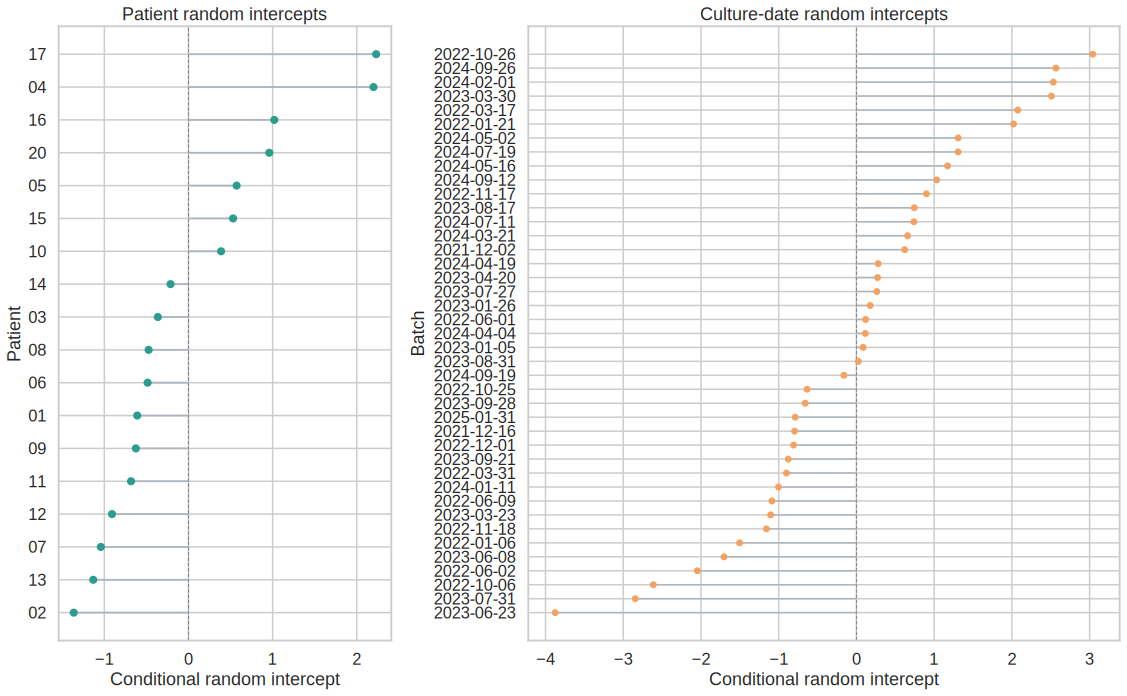

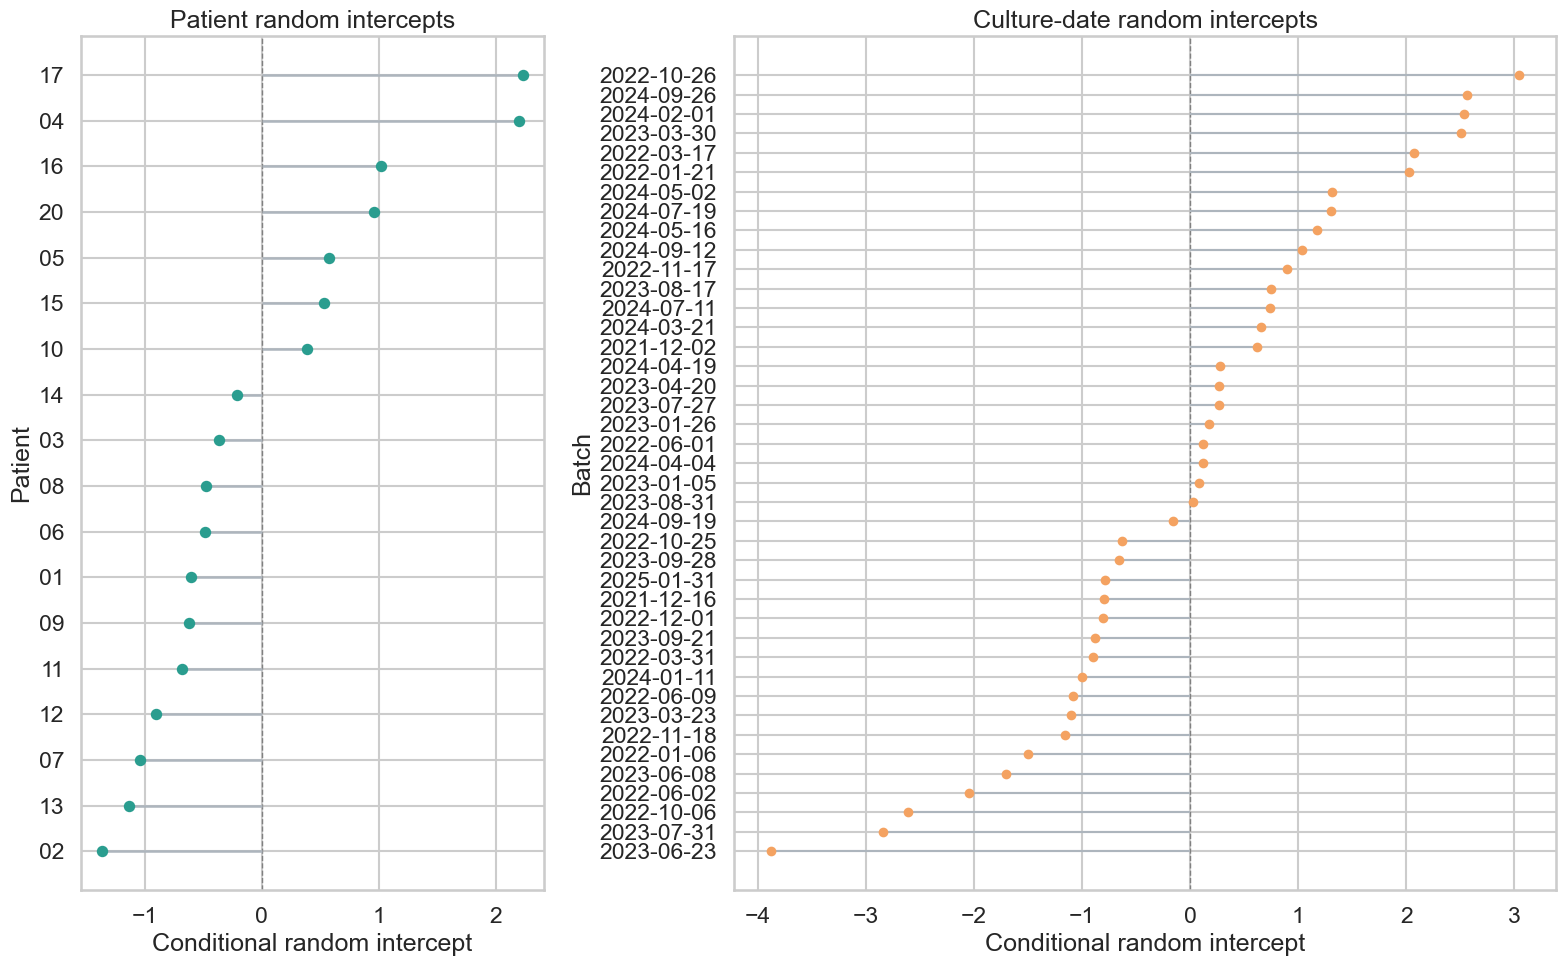

In [7]:
patient_df = random_effects_df.loc[random_effects_df["group"] == "patient"].sort_values(
    "random_intercept"
)
batch_df = random_effects_df.loc[random_effects_df["group"] == "batch"].sort_values(
    "random_intercept"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 10), gridspec_kw={"width_ratios": [0.9, 1.6]})

axes[0].axvline(0, color="grey", linestyle="--", linewidth=1)
axes[0].hlines(patient_df["level"], 0, patient_df["random_intercept"], color="#adb5bd", linewidth=1.8)
axes[0].scatter(patient_df["random_intercept"], patient_df["level"], color="#2a9d8f", s=45, zorder=3)
axes[0].set_title("Patient random intercepts")
axes[0].set_xlabel("Conditional random intercept")
axes[0].set_ylabel("Patient")

axes[1].axvline(0, color="grey", linestyle="--", linewidth=1)
axes[1].hlines(batch_df["level"], 0, batch_df["random_intercept"], color="#adb5bd", linewidth=1.5)
axes[1].scatter(batch_df["random_intercept"], batch_df["level"], color="#f4a261", s=30, zorder=3)
axes[1].set_title("Culture-date random intercepts")
axes[1].set_xlabel("Conditional random intercept")
axes[1].set_ylabel("Batch")

fig.tight_layout()
fig_14_04_path = wc.figure_path(context, 21, "host_gaussian_random_intercepts")
fig.savefig(fig_14_04_path, bbox_inches="tight")
fig.savefig(fig_14_04_path.with_suffix(".jpg"), bbox_inches="tight", dpi=300)
display(SVG(filename=str(fig_14_04_path)))

## Review Main Host Outputs

In [8]:
display(Markdown("### table_14_01_host_gaussian_followup"))
display(pd.read_csv(wc.table_path(context, 36, "host_gaussian_followup"), sep="\t").head(20))
display(Markdown("### table_14_02_host_gaussian_random_effects"))
display(pd.read_csv(wc.table_path(context, 37, "host_gaussian_random_effects"), sep="\t").head(20))
display(Markdown("### table_14_03_host_descriptive_utests"))
display(pd.read_csv(context.table_dir / "table_14_03_host_descriptive_utests.tsv", sep="\t"))

,model_name,term,term_label,estimate,conf_low,conf_high,pvalue,qvalue,factor_family,posthoc_qvalue,record_type,lrt_statistic,df_diff
0,host_model,"C(chronicity_group, Treatment('unknown'))[T.ac...",Acute-like vs unknown,2.703658,0.320482,5.086834,0.026180,0.235618,chronicity_group,0.078539,full_model_term,NaN,NaN
1,host_model,"C(body_region, Treatment('lower_extremity'))[T...",Upper extremity vs lower extremity,1.639654,-0.151391,3.430699,0.072766,0.327448,body_region,0.218298,full_model_term,NaN,NaN
2,host_model,"C(body_region, Treatment('lower_extremity'))[T...",Trunk / perineum vs lower extremity,0.820328,-1.008202,2.648858,0.379243,0.890779,body_region,0.434183,full_model_term,NaN,NaN
3,host_model,"C(body_region, Treatment('lower_extremity'))[T...",Head / neck vs lower extremity,0.919000,-1.384173,3.222173,0.434183,0.890779,body_region,0.434183,full_model_term,NaN,NaN
4,host_model,"C(chronicity_group, Treatment('unknown'))[T.ch...",Chronic-like vs unknown,0.871255,-1.630501,3.373010,0.494877,0.890779,chronicity_group,0.742316,full_model_term,NaN,NaN
5,host_model,years_since_first_sample,Per year since first patient sample,0.244312,-1.261803,1.750428,0.750536,0.963054,elapsed_time,0.750536,full_model_term,NaN,NaN
6,host_model,"C(chronicity_group, Treatment('unknown'))[T.mi...",Mixed vs unknown,0.369669,-3.922666,4.662005,0.865955,0.963054,chronicity_group,0.865955,full_model_term,NaN,NaN
7,host_model,"C(culture_positive_label, Treatment('negative'...",Culture positive vs negative,0.065453,-2.582111,2.713017,0.961354,0.963054,culture_positive,0.961354,full_model_term,NaN,NaN
8,host_model,body_region_overall,Body region overall,NaN,NaN,NaN,0.303682,NaN,body_region,NaN,omnibus_test,3.634906,3.0
9,host_model,chronicity_group_overall,Chronicity overall,NaN,NaN,NaN,0.090659,NaN,chronicity_group,NaN,omnibus_test,6.474854,3.0


,group,level,random_intercept
0,batch,2023-06-23,-3.875546
1,batch,2023-07-31,-2.845485
2,batch,2022-10-06,-2.612772
3,batch,2022-06-02,-2.047101
4,batch,2023-06-08,-1.703279
5,batch,2022-01-06,-1.503167
6,batch,2022-11-18,-1.158527
7,batch,2023-03-23,-1.104011
8,batch,2022-06-09,-1.086355
9,batch,2024-01-11,-1.002590
